# 09 Regularized XGBoost Simplification

Notebook 08 showed a visible train-validation gap, especially for the deeper tuned models.

This notebook keeps the same full-data time split and the same `v2_full` feature set, then tests whether a slightly simpler XGBoost improves validation behavior.


## Setup

The comparison is intentionally narrow:

- `v2_full_reference`: the original full-data reference model
- `tuned_params_no_class_weight`: the strongest model from notebook 08
- `tuned_cost_sensitive_xgb`: the cost-sensitive version from notebook 07/08
- `regularized_depth6_no_weight`: a smaller depth-6 version with stronger regularization
- `regularized_depth5_no_weight`: a smaller depth-5 version with stronger regularization

The business threshold section uses `FN:FP = 10:1` in this notebook.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.data_prep_safe import load_merged_data_safe, make_time_validation_split
from src.fraud_detection.eda import set_plot_theme
from src.fraud_detection.metrics import compute_classification_metrics
from src.fraud_detection.tree_preprocessing_v2 import fit_tree_preprocessor_v2, transform_tree_preprocessor_v2

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

RANDOM_STATE = 42
FN_COST = 10
FP_COST = 1
THRESHOLDS = np.unique(
    np.r_[
        np.linspace(0.001, 0.050, 50),
        np.linspace(0.055, 0.500, 90),
        np.linspace(0.510, 0.990, 49),
    ]
)
MODEL_COLORS = {
    "v2_full_reference": "#2563eb",
    "tuned_params_no_class_weight": "#64748b",
    "tuned_cost_sensitive_xgb": "#dc2626",
    "regularized_depth6_no_weight": "#16a34a",
    "regularized_depth5_no_weight": "#f59e0b",
}
OUTPUT_PATH = PROJECT_ROOT / "outputs" / "regularized_xgboost_simplification_summary.json"


## Full-Data Time Split And Features


In [2]:
train_df, _ = load_merged_data_safe(nrows=None)
train_part, valid_part = make_time_validation_split(train_df)

artifacts = fit_tree_preprocessor_v2(
    train_part,
    add_missing_indicators=True,
    add_group_amount_features=True,
    drop_missing_threshold=0.999,
)

x_train = transform_tree_preprocessor_v2(train_part, artifacts, impute_numeric=False)
x_valid = transform_tree_preprocessor_v2(valid_part, artifacts, impute_numeric=False)
y_train = train_part["isFraud"].to_numpy()
y_valid = valid_part["isFraud"].to_numpy()

positive_count = int(y_train.sum())
negative_count = int(len(y_train) - positive_count)
base_scale_pos_weight = negative_count / max(1, positive_count)

setup_summary = pd.DataFrame(
    [
        ["labelled_rows", len(train_df)],
        ["train_rows", len(train_part)],
        ["validation_rows", len(valid_part)],
        ["train_fraud_rate", y_train.mean()],
        ["validation_fraud_rate", y_valid.mean()],
        ["feature_count", x_train.shape[1]],
        ["base_scale_pos_weight", base_scale_pos_weight],
    ],
    columns=["item", "value"],
)
display(setup_summary.style.hide(axis="index"))


item,value
labelled_rows,590540.000000
train_rows,472432.000000
validation_rows,118108.000000
train_fraud_rate,0.035135
validation_fraud_rate,0.034409
feature_count,807.000000
base_scale_pos_weight,27.461474


## Candidate Models


In [3]:
def make_xgb(params):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    )


model_configs = {
    "v2_full_reference": {
        "n_estimators": 400,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
    },
    "tuned_params_no_class_weight": {
        "n_estimators": 700,
        "max_depth": 8,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 3,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "gamma": 0.0,
        "scale_pos_weight": 1.0,
    },
    "tuned_cost_sensitive_xgb": {
        "n_estimators": 700,
        "max_depth": 8,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 3,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "gamma": 0.0,
        "scale_pos_weight": base_scale_pos_weight * 0.65,
    },
    "regularized_depth6_no_weight": {
        "n_estimators": 650,
        "max_depth": 6,
        "learning_rate": 0.03,
        "subsample": 0.82,
        "colsample_bytree": 0.75,
        "min_child_weight": 6,
        "reg_lambda": 6.0,
        "reg_alpha": 0.25,
        "gamma": 0.10,
        "scale_pos_weight": 1.0,
    },
    "regularized_depth5_no_weight": {
        "n_estimators": 550,
        "max_depth": 5,
        "learning_rate": 0.04,
        "subsample": 0.85,
        "colsample_bytree": 0.75,
        "min_child_weight": 8,
        "reg_lambda": 10.0,
        "reg_alpha": 0.50,
        "gamma": 0.25,
        "scale_pos_weight": 1.0,
    },
}

model_summary = pd.DataFrame(
    [
        {
            "model": model_name,
            "n_estimators": params.get("n_estimators"),
            "max_depth": params.get("max_depth"),
            "learning_rate": params.get("learning_rate"),
            "min_child_weight": params.get("min_child_weight", np.nan),
            "reg_lambda": params.get("reg_lambda", np.nan),
            "reg_alpha": params.get("reg_alpha", 0.0),
            "gamma": params.get("gamma", 0.0),
            "scale_pos_weight": params.get("scale_pos_weight", 1.0),
        }
        for model_name, params in model_configs.items()
    ]
)
display(model_summary.style.hide(axis="index"))


model,n_estimators,max_depth,learning_rate,min_child_weight,reg_lambda,reg_alpha,gamma,scale_pos_weight
v2_full_reference,400,6,0.050000,nan,1.000000,0.000000,0.000000,1.000000
tuned_params_no_class_weight,700,8,0.030000,3.000000,2.000000,0.100000,0.000000,1.000000
tuned_cost_sensitive_xgb,700,8,0.030000,3.000000,2.000000,0.100000,0.000000,17.849958
regularized_depth6_no_weight,650,6,0.030000,6.000000,6.000000,0.250000,0.100000,1.000000
regularized_depth5_no_weight,550,5,0.040000,8.000000,10.000000,0.500000,0.250000,1.000000


## Train And Evaluate


In [4]:
def threshold_policy_table(y_true, y_score, model_name, thresholds=THRESHOLDS, fn_cost=FN_COST, fp_cost=FP_COST):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    rows = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        tp = int(np.sum((y_pred == 1) & (y_true == 1)))
        fp = int(np.sum((y_pred == 1) & (y_true == 0)))
        fn = int(np.sum((y_pred == 0) & (y_true == 1)))
        tn = int(np.sum((y_pred == 0) & (y_true == 0)))
        total_cost = fn_cost * fn + fp_cost * fp
        rows.append(
            {
                "model": model_name,
                "threshold": float(threshold),
                "true_positives": tp,
                "false_positives": fp,
                "false_negatives": fn,
                "true_negatives": tn,
                "precision": tp / max(1, tp + fp),
                "recall": tp / max(1, tp + fn),
                "review_rate": (tp + fp) / len(y_true),
                "total_cost": total_cost,
                "cost_per_1k_txn": total_cost / len(y_true) * 1000,
            }
        )

    return pd.DataFrame(rows)


fitted_models = {}
score_by_model = {}
threshold_tables = {}
metric_rows = []
generalization_rows = []

for model_name, params in model_configs.items():
    model = make_xgb(params)
    model.fit(x_train, y_train)

    train_scores = model.predict_proba(x_train)[:, 1]
    valid_scores = model.predict_proba(x_valid)[:, 1]
    fitted_models[model_name] = model
    score_by_model[model_name] = valid_scores

    train_metrics = compute_classification_metrics(
        y_train,
        train_scores,
        top_fractions=(0.01, 0.03, 0.05),
    )
    valid_metrics = compute_classification_metrics(
        y_valid,
        valid_scores,
        top_fractions=(0.01, 0.03, 0.05),
    )

    for split_name, metrics in [("train", train_metrics), ("validation", valid_metrics)]:
        generalization_rows.append(
            {
                "model": model_name,
                "split": split_name,
                "roc_auc": metrics["roc_auc"],
                "pr_auc": metrics["average_precision"],
                "precision_at_top_3pct": metrics["precision_at_top_3pct"],
                "recall_at_top_3pct": metrics["recall_at_top_3pct"],
                "precision_at_top_5pct": metrics["precision_at_top_5pct"],
                "recall_at_top_5pct": metrics["recall_at_top_5pct"],
            }
        )

    threshold_table = threshold_policy_table(y_valid, valid_scores, model_name)
    threshold_tables[model_name] = threshold_table
    best_policy = threshold_table.sort_values(
        ["total_cost", "false_negatives", "review_rate"],
        ascending=[True, True, True],
    ).iloc[0]

    metric_rows.append(
        {
            "model": model_name,
            "validation_roc_auc": valid_metrics["roc_auc"],
            "validation_pr_auc": valid_metrics["average_precision"],
            "validation_precision_at_top_3pct": valid_metrics["precision_at_top_3pct"],
            "validation_recall_at_top_3pct": valid_metrics["recall_at_top_3pct"],
            "validation_precision_at_top_5pct": valid_metrics["precision_at_top_5pct"],
            "validation_recall_at_top_5pct": valid_metrics["recall_at_top_5pct"],
            "train_pr_auc": train_metrics["average_precision"],
            "pr_auc_gap": train_metrics["average_precision"] - valid_metrics["average_precision"],
            "optimized_threshold": best_policy["threshold"],
            "optimized_false_positives": best_policy["false_positives"],
            "optimized_false_negatives": best_policy["false_negatives"],
            "optimized_recall": best_policy["recall"],
            "optimized_review_rate": best_policy["review_rate"],
            "optimized_cost_per_1k_txn": best_policy["cost_per_1k_txn"],
        }
    )

model_results = pd.DataFrame(metric_rows).sort_values(
    ["validation_pr_auc", "optimized_cost_per_1k_txn"],
    ascending=[False, True],
)
generalization_metrics = pd.DataFrame(generalization_rows)

display(model_results.style.hide(axis="index"))


model,validation_roc_auc,validation_pr_auc,validation_precision_at_top_3pct,validation_recall_at_top_3pct,validation_precision_at_top_5pct,validation_recall_at_top_5pct,train_pr_auc,pr_auc_gap,optimized_threshold,optimized_false_positives,optimized_false_negatives,optimized_recall,optimized_review_rate,optimized_cost_per_1k_txn
tuned_params_no_class_weight,0.924168,0.583864,0.601016,0.524114,0.433796,0.630413,0.885701,0.301837,0.085000,5024,1290,0.682579,0.066024,151.759407
tuned_cost_sensitive_xgb,0.921506,0.569229,0.586061,0.511073,0.423976,0.616142,0.914317,0.345088,0.415000,5129,1343,0.669537,0.066465,157.135842
v2_full_reference,0.911789,0.553101,0.569413,0.496555,0.411954,0.598671,0.798864,0.245763,0.075000,6688,1254,0.691437,0.080418,162.800149
regularized_depth6_no_weight,0.908887,0.543419,0.558973,0.487451,0.401795,0.583907,0.760529,0.217110,0.095000,5136,1438,0.646161,0.065720,165.238595
regularized_depth5_no_weight,0.904128,0.524947,0.538939,0.469980,0.393837,0.572343,0.716280,0.191332,0.095000,5440,1483,0.635089,0.067912,171.622583


## Train vs Validation Gap


model,split,roc_auc,pr_auc,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_5pct,recall_at_top_5pct
regularized_depth5_no_weight,train,0.941127,0.716280,0.731814,0.624857,0.504784,0.718357
regularized_depth5_no_weight,validation,0.904128,0.524947,0.538939,0.469980,0.393837,0.572343
regularized_depth6_no_weight,train,0.952853,0.760529,0.775841,0.662450,0.530861,0.755467
regularized_depth6_no_weight,validation,0.908887,0.543419,0.558973,0.487451,0.401795,0.583907
tuned_cost_sensitive_xgb,train,0.993736,0.914317,0.909970,0.776975,0.644230,0.916802
tuned_cost_sensitive_xgb,validation,0.921506,0.569229,0.586061,0.511073,0.423976,0.616142
tuned_params_no_class_weight,train,0.982879,0.885701,0.909335,0.776432,0.612988,0.872342
tuned_params_no_class_weight,validation,0.924168,0.583864,0.601016,0.524114,0.433796,0.630413
v2_full_reference,train,0.961792,0.798864,0.816270,0.696970,0.556896,0.792518
v2_full_reference,validation,0.911789,0.553101,0.569413,0.496555,0.411954,0.598671


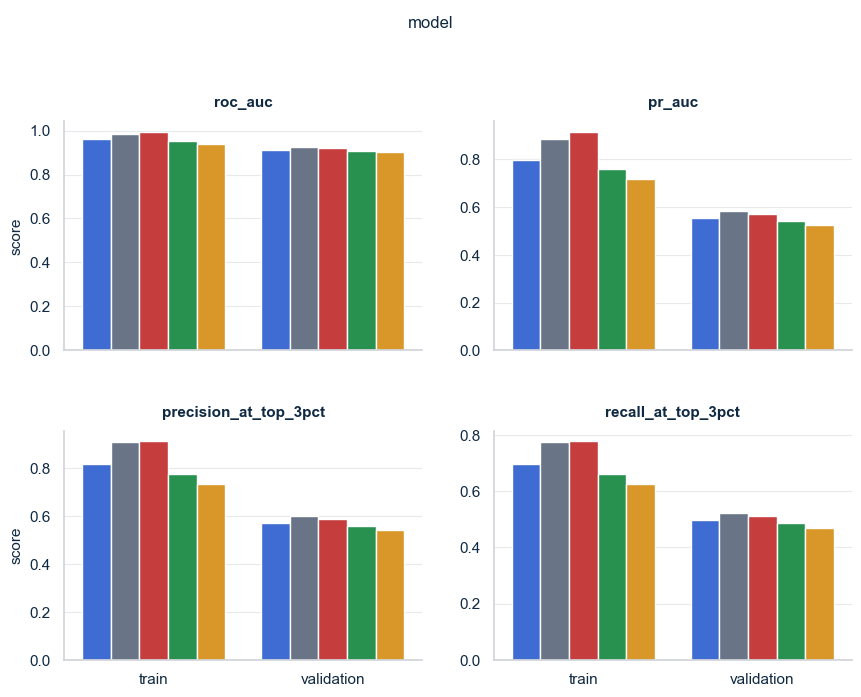

In [5]:
display(
    generalization_metrics.sort_values(["model", "split"]).style.hide(axis="index")
)

gap_plot = generalization_metrics.melt(
    id_vars=["model", "split"],
    value_vars=["roc_auc", "pr_auc", "precision_at_top_3pct", "recall_at_top_3pct"],
    var_name="metric",
    value_name="value",
)

g = sns.catplot(
    data=gap_plot,
    x="split",
    y="value",
    hue="model",
    col="metric",
    kind="bar",
    palette=MODEL_COLORS,
    col_wrap=2,
    height=3.5,
    aspect=1.25,
    sharey=False,
    legend=False,
)
g.set_titles("{col_name}")
g.set_axis_labels("", "score")
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.fig.legend(
    handles,
    labels,
    title="model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    frameon=False,
)
g.fig.subplots_adjust(top=0.86, hspace=0.35, wspace=0.20)
plt.show()


## Validation Ranking And Cost


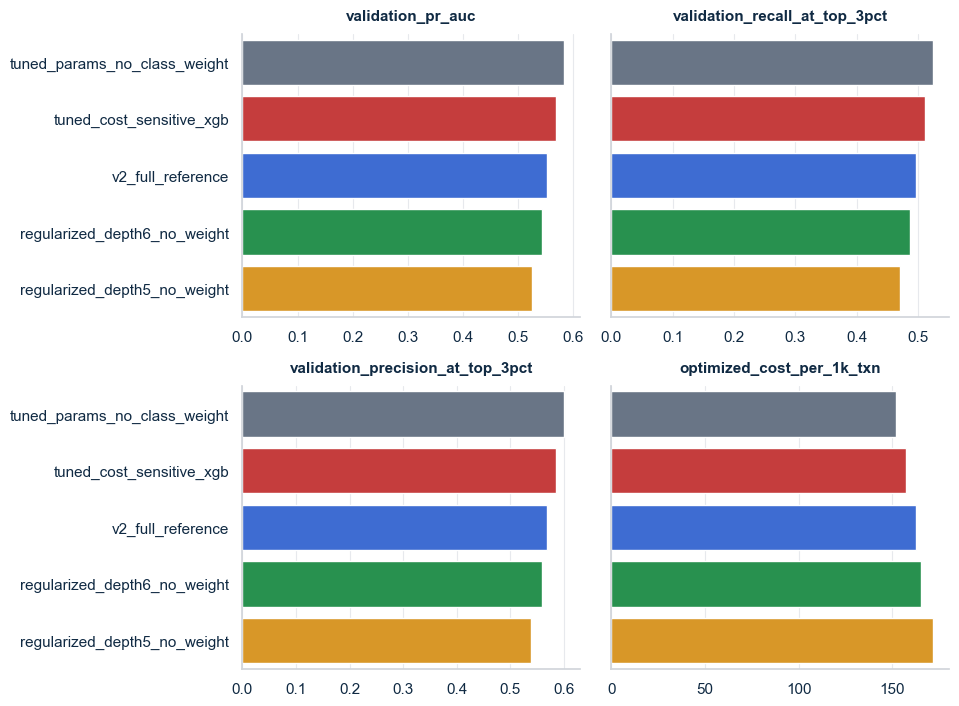

In [6]:
plot_metrics = model_results.melt(
    id_vars=["model"],
    value_vars=[
        "validation_pr_auc",
        "validation_recall_at_top_3pct",
        "validation_precision_at_top_3pct",
        "optimized_cost_per_1k_txn",
    ],
    var_name="metric",
    value_name="value",
)

g = sns.catplot(
    data=plot_metrics,
    x="value",
    y="model",
    col="metric",
    kind="bar",
    palette=[MODEL_COLORS.get(model, "#64748b") for model in model_results["model"]],
    col_wrap=2,
    height=3.6,
    aspect=1.35,
    sharex=False,
)
g.set_titles("{col_name}")
g.set_axis_labels("", "")
plt.tight_layout()
plt.show()


## Threshold Curves For The Leading Models


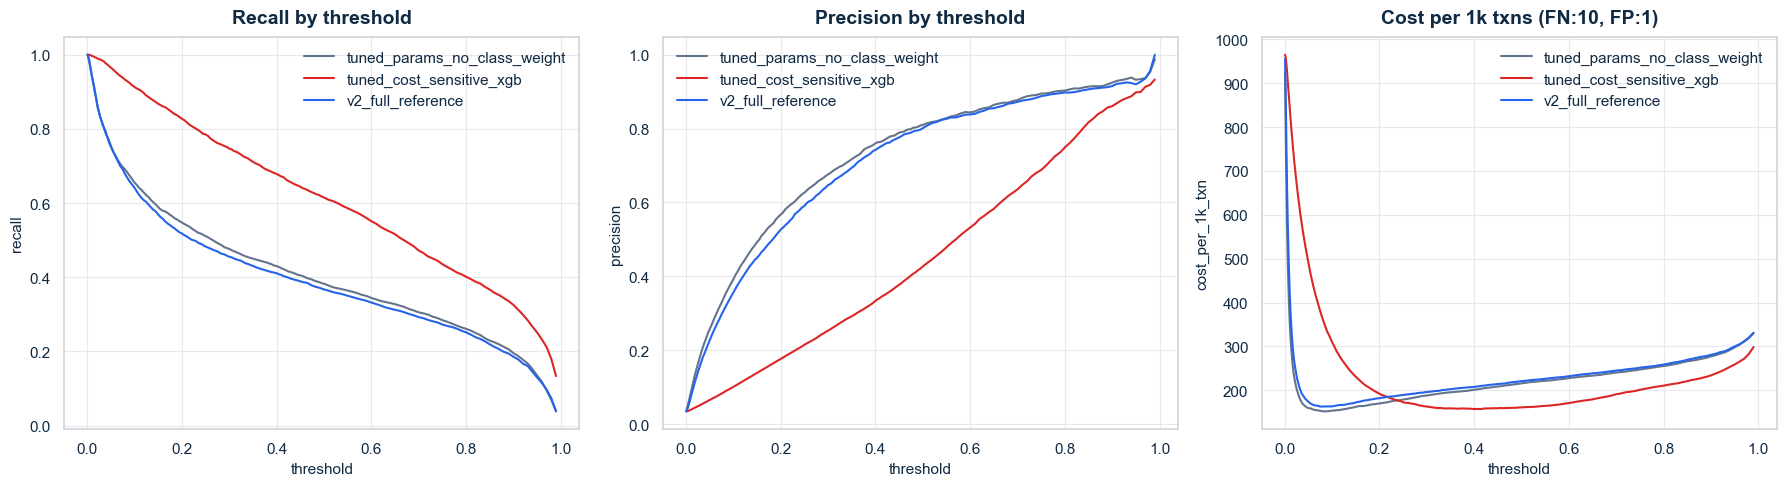

In [7]:
leading_models = model_results.head(3)["model"].tolist()
threshold_plot = pd.concat(
    [threshold_tables[model] for model in leading_models],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for metric, ax, title in [
    ("recall", axes[0], "Recall by threshold"),
    ("precision", axes[1], "Precision by threshold"),
    ("cost_per_1k_txn", axes[2], f"Cost per 1k txns (FN:{FN_COST}, FP:{FP_COST})"),
]:
    sns.lineplot(
        data=threshold_plot,
        x="threshold",
        y=metric,
        hue="model",
        palette=MODEL_COLORS,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("threshold")
    ax.legend(title="")

plt.tight_layout()
plt.show()


## Optimized Confusion Matrices


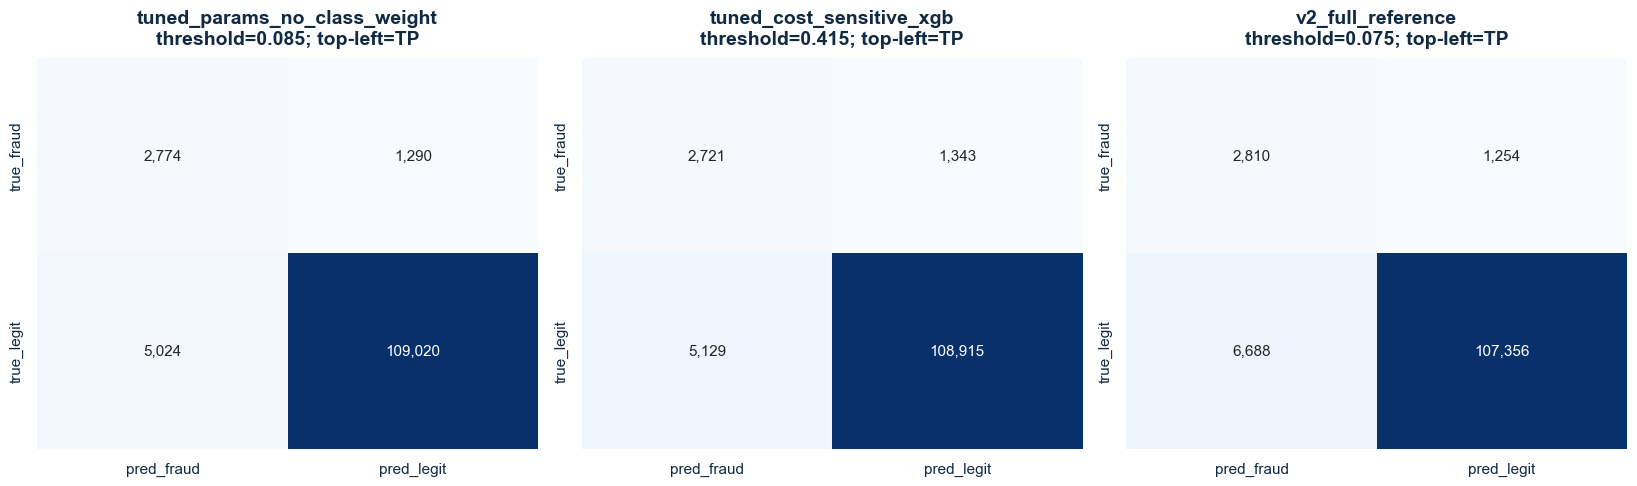

In [8]:
def confusion_counts_at_threshold(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    return confusion_matrix(y_true, y_pred, labels=[1, 0])


leading = model_results.head(3).copy()
fig, axes = plt.subplots(1, len(leading), figsize=(5.5 * len(leading), 5))

for ax, row in zip(axes, leading.itertuples(index=False)):
    matrix = confusion_counts_at_threshold(
        y_valid,
        score_by_model[row.model],
        row.optimized_threshold,
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        xticklabels=["pred_fraud", "pred_legit"],
        yticklabels=["true_fraud", "true_legit"],
        ax=ax,
    )
    ax.set_title(f"{row.model}\nthreshold={row.optimized_threshold:.3f}; top-left=TP")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


## Reading The Result


In [9]:
best_model = model_results.iloc[0]
reference = model_results.loc[model_results["model"] == "v2_full_reference"].iloc[0]

report_summary = pd.DataFrame(
    [
        {
            "question": "Best validation PR-AUC model",
            "answer": best_model["model"],
        },
        {
            "question": "PR-AUC lift vs v2_full_reference",
            "answer": best_model["validation_pr_auc"] - reference["validation_pr_auc"],
        },
        {
            "question": "Cost per 1k improvement vs v2_full_reference",
            "answer": reference["optimized_cost_per_1k_txn"] - best_model["optimized_cost_per_1k_txn"],
        },
        {
            "question": "False negatives reduced vs v2_full_reference",
            "answer": reference["optimized_false_negatives"] - best_model["optimized_false_negatives"],
        },
        {
            "question": "PR-AUC train-validation gap",
            "answer": best_model["pr_auc_gap"],
        },
    ]
)
display(report_summary.style.hide(axis="index"))

recommendation = (
    f"Use {best_model['model']} for the current validation-backed policy. "
    "The simplification pass did not replace it unless another candidate ranks first above."
)
print(recommendation)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(
    json.dumps(
        {
            "model_results": model_results.to_dict(orient="records"),
            "generalization_metrics": generalization_metrics.to_dict(orient="records"),
            "recommendation": recommendation,
        },
        indent=2,
    ),
    encoding="utf-8",
)
print(f"Saved {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")


question,answer
Best validation PR-AUC model,tuned_params_no_class_weight
PR-AUC lift vs v2_full_reference,0.030763
Cost per 1k improvement vs v2_full_reference,11.040742
False negatives reduced vs v2_full_reference,-36
PR-AUC train-validation gap,0.301837


Use tuned_params_no_class_weight for the current validation-backed policy. The simplification pass did not replace it unless another candidate ranks first above.
Saved outputs/regularized_xgboost_simplification_summary.json
